In [ ]:
"""
Well Turbidity Analysis using Hough Circle Detection

This script:
1. Detects circular wells in 3x4 plate images.
2. Crops inner regions of each well.
3. Computes turbidity-related metrics:
      - Contrast (std deviation)
      - Laplacian variance (sharpness / blur)
      - Mean intensity
4. Aggregates results row-wise.
5. Outputs a Time x Row x Metric array.

Designed for bacterial growth / turbidity monitoring.
"""

!pip install opencv-python numpy matplotlib

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================================
# 1. WELL DETECTION
# ==========================================================

def detect_wells(image_path,
                 shrink_factor,
                 visualize,
                 debug,
                 expected_wells,
                 blur_kernel,
                 blur_sigma,
                 hough_dp,
                 hough_minDist,
                 hough_param1,
                 hough_param2,
                 hough_minRadius,
                 hough_maxRadius,
                 fallback_minDist,
                 fallback_param2,
                 fallback_minRadius,
                 fallback_maxRadius):
    """
    Detect circular wells using Hough Circle Transform.

    Workflow:
    1. Convert image to grayscale.
    2. Apply Gaussian blur to stabilize circle detection.
    3. Run HoughCircles with primary parameters.
    4. If number of detected wells != expected_wells,
       run fallback detection with stricter parameters.

    Parameters
    ----------
    shrink_factor : float
        Fraction of detected radius used for measurement.
        Smaller values exclude well wall reflections.

    debug : bool
        Shows intermediate preprocessing steps.

    visualize : bool
        Overlays detected circles on image.

    expected_wells : int
        Number of wells expected (e.g., 12 for 3x4 plate).

    Hough Parameters:
    ------------------
    hough_dp :
        Inverse resolution ratio for accumulator.
        Usually 1.2 works well.

    hough_minDist :
        Minimum allowed distance between circle centers.
        Increase if duplicate circles appear.

    hough_param1 :
        Higher Canny threshold (internal edge detection).

    hough_param2 :
        Accumulator threshold.
        Lower → more circles detected.
        Higher → stricter detection.

    hough_minRadius / hough_maxRadius :
        Allowed radius range.
        Tightening this reduces false detections.

    Fallback parameters:
        Used if first detection does not match expected_wells.
        Typically stricter to reduce false positives.
    """

    img = cv2.imread(image_path)

    # Debug: show original
    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Original")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Grayscale")
        plt.imshow(gray, cmap="gray")
        plt.axis("off")
        plt.show()

    # Gaussian smoothing improves stability of Hough detection
    blur = cv2.GaussianBlur(gray, blur_kernel, blur_sigma)

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Gaussian Blur")
        plt.imshow(blur, cmap="gray")
        plt.axis("off")
        plt.show()

    # -------- Primary Detection --------
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=hough_dp,
        minDist=hough_minDist,
        param1=hough_param1,
        param2=hough_param2,
        minRadius=hough_minRadius,
        maxRadius=hough_maxRadius
    )

    detected = len(circles[0]) if circles is not None else 0
    print(f"Initial circles detected: {detected}")

    # -------- Fallback Detection --------
    if detected != expected_wells:
        circles = cv2.HoughCircles(
            blur,
            cv2.HOUGH_GRADIENT,
            dp=hough_dp,
            minDist=fallback_minDist,
            param1=hough_param1,
            param2=fallback_param2,
            minRadius=fallback_minRadius,
            maxRadius=fallback_maxRadius
        )

    vis = img.copy()

    if circles is None:
        print("No circles detected")
        circles = []
    else:
        circles = np.round(circles[0]).astype(int)
        circles = sorted(circles, key=lambda c: (c[1], c[0]))

        if visualize:
            for (x, y, r) in circles:
                r_inner = int(r * shrink_factor)

                # Green = detected outer boundary
                cv2.circle(vis, (x, y), r, (0,255,0), 2)

                # Blue = region used for metric computation
                cv2.circle(vis, (x, y), r_inner, (255,0,0), 2)

                # Red = center
                cv2.circle(vis, (x, y), 3, (0,0,255), -1)

            print(f"Final detected circles: {len(circles)}")

            plt.figure(figsize=(8,6))
            plt.title("Final Detection")
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

    return img, circles

In [3]:
# ==========================================================
# 2. WELL CROPPING
# ==========================================================

def crop_wells(img, circles, shrink_factor):
    """
    Crop inner square region of each detected well.

    shrink_factor controls how much of the detected radius
    is used for measurement.

    Smaller → avoids well wall reflections.
    Larger → includes more of liquid region.
    """
    wells = []

    for (x, y, r) in circles:
        r_inner = int(r * shrink_factor)
        crop = img[y-r_inner:y+r_inner, x-r_inner:x+r_inner]
        wells.append(crop)

    return wells

In [4]:
# ==========================================================
# 3. METRIC COMPUTATION
# ==========================================================

def well_metrics(well):
    """
    Compute turbidity-related metrics:

    contrast:
        Standard deviation of intensity.
        Lower as turbidity increases.

    laplacian_var:
        Sharpness measure (blur).
        Lower = more blur = more turbidity.

    mean_int:
        Average brightness.
    """

    gray = cv2.cvtColor(well, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    center = (w//2, h//2)
    radius = min(center)

    mask = np.zeros_like(gray)
    cv2.circle(mask, center, radius, 255, -1)

    pixels = gray[mask == 255]

    contrast = np.std(pixels)
    laplacian_var = cv2.Laplacian(pixels, cv2.CV_64F).var()
    mean_int = np.mean(pixels)

    return contrast, laplacian_var, mean_int



In [16]:
# ==========================================================
# 4. ROW AVERAGING
# ==========================================================

def row_averages(metrics, expected_wells, num_rows):
    """
    Compute row-wise averages.

    Parameters
    ----------
    metrics : ndarray
        Array of shape (expected_wells, num_metrics)

    expected_wells : int
        Total number of detected wells.

    num_rows : int
        Number of well rows in the plate layout.

    Notes
    -----
    Assumes wells are ordered row-major
    (left-to-right, top-to-bottom).
    """

    wells_per_row = expected_wells // num_rows

    row_data = []
    for i in range(0, expected_wells, wells_per_row):
        row = metrics[i:i+wells_per_row]
        row_data.append(np.mean(row, axis=0))

    return np.array(row_data)


In [14]:
# =========================
# USER CONFIGURATION
# =========================

FOLDER_PATH = "Earth"

EXPECTED_WELLS = 12      # Change if plate layout changes
NUM_ROWS = 3             # Number of rows in the plate (e.g., 3 for 3x4 layout)

# --- Crop ---
SHRINK_FACTOR = 0.3      # Smaller excludes wall reflections

# --- Debug / Visualization ---
DEBUG = False            # Show intermediate steps for troubleshooting
VISUALIZE = True         # Show detected circles on images

# --- Blur ---
BLUR_KERNEL = (9,9)      # Larger → smoother → fewer false edges
BLUR_SIGMA = 2           # Controls smoothing strength

# --- Primary Hough ---
HOUGH_DP = 1.2
HOUGH_MIN_DIST = 150     # Increase if duplicate detections
HOUGH_PARAM1 = 100
HOUGH_PARAM2 = 30        # Lower → more circles detected
HOUGH_MIN_RADIUS = 80
HOUGH_MAX_RADIUS = 150

# --- Fallback Hough ---
FALLBACK_MIN_DIST = 300
FALLBACK_PARAM2 = 40     # Stricter threshold
FALLBACK_MIN_RADIUS = 150
FALLBACK_MAX_RADIUS = 200



Processing: Earth\20260129 151049.png
Initial circles detected: 12
Final detected circles: 12


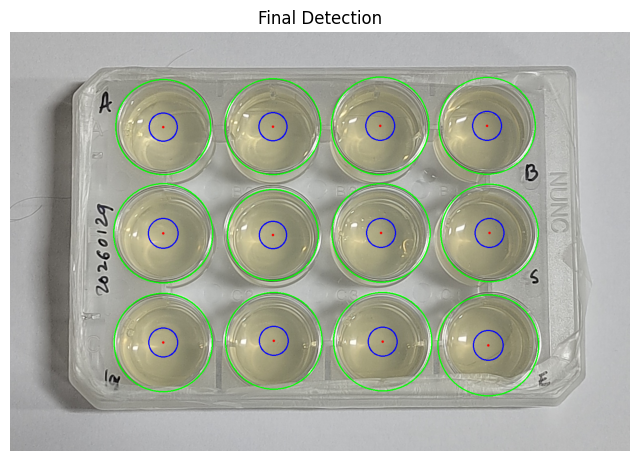


Processing: Earth\20260129 173542.png
Initial circles detected: 12
Final detected circles: 12


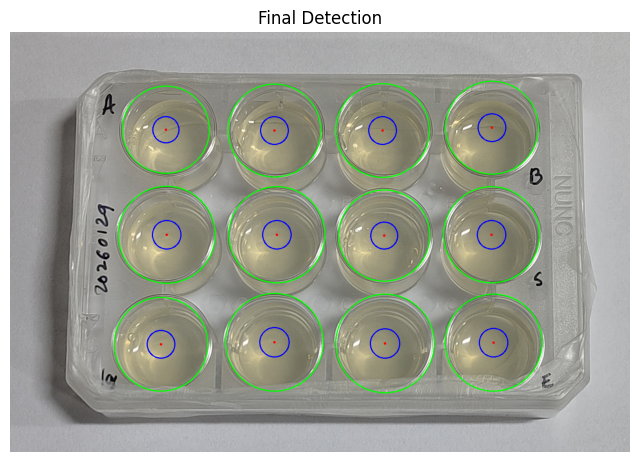


Processing: Earth\20260129 190848.png
Initial circles detected: 12
Final detected circles: 12


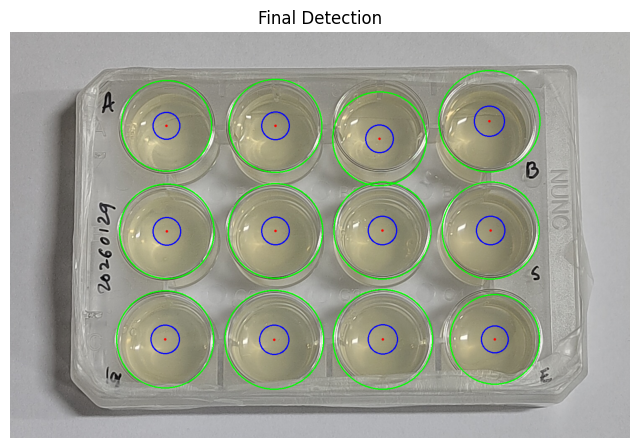


Processing: Earth\20260130 121150.png
Initial circles detected: 12
Final detected circles: 12


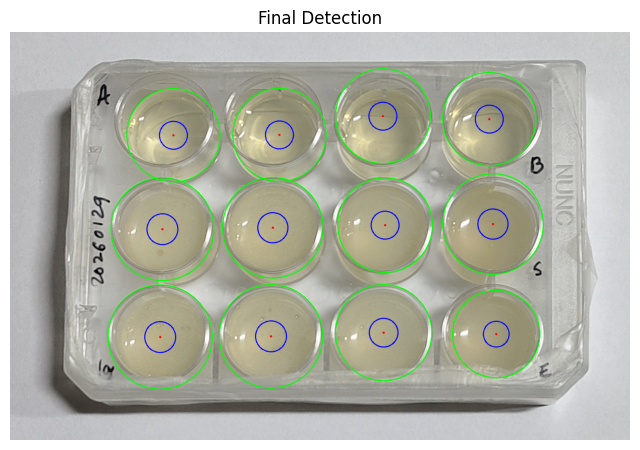


Processing: Earth\20260130 163823.png
Initial circles detected: 12
Final detected circles: 12


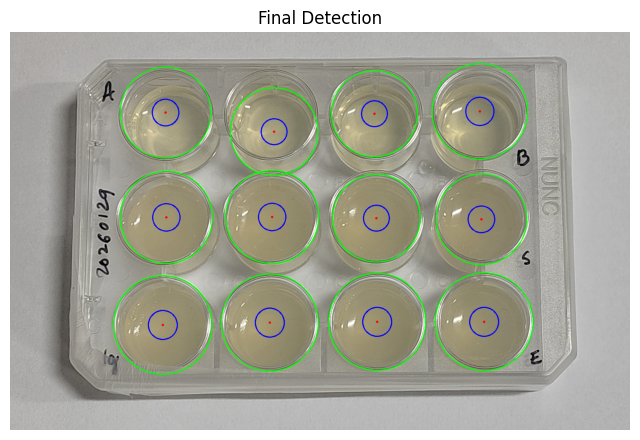


Processing: Earth\20260130 192318.png
Initial circles detected: 12
Final detected circles: 12


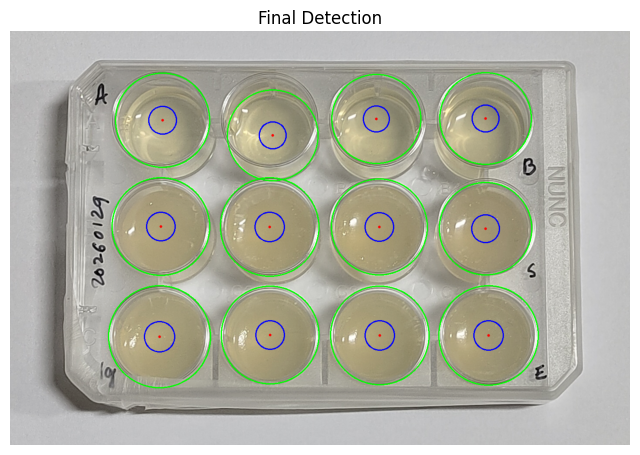


Processing: Earth\20260131 142811.png
Initial circles detected: 12
Final detected circles: 12


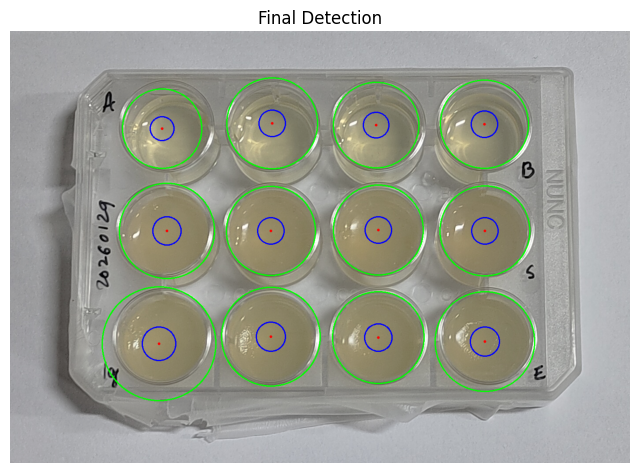


Final Output Summary
Data dimensions (# of Images x Well Rows x Measurements): (7, 3, 3)


Row-wise averages (Contrast, Sharpness, Mean Intensity): 
[[[  9.98703151  32.11003936 154.59775766]
  [ 10.86001533  44.95607203 158.01795657]
  [ 10.55045556  42.58002265 157.15085128]]

 [[  8.59327494  19.56674258 137.81599402]
  [  8.92121     24.02288792 142.86066928]
  [  9.91625882  30.99406573 144.85868348]]

 [[  8.67864579  25.54046908 146.70147744]
  [  8.52199165  26.97390939 151.36499125]
  [  8.56923471  29.81220745 152.25715163]]

 [[ 10.58476428  26.38062477 158.76972955]
  [  3.76920152   6.05630232 165.8844531 ]
  [  5.15317481   9.97842749 166.95958616]]

 [[  8.84652293  22.46529436 146.41162059]
  [  3.16747339   5.83026805 143.94266876]
  [  4.37072915   9.37258211 145.03495689]]

 [[  9.31676211  29.29336593 161.07840096]
  [  3.55840497   6.69802133 156.30400212]
  [  4.78442504  10.00115863 158.73678352]]

 [[  8.73642145  26.83172718 139.98557918]
  [  2.98967579   6.1

In [ ]:
# ==========================================================
# MAIN EXECUTION PIPELINE
# ==========================================================
"""
Main Processing Loop

For each image in FOLDER_PATH:

1. Detect circular wells using Hough transform.
2. Crop inner region of each well.
3. Compute turbidity-related metrics:
       - Contrast (intensity standard deviation)
       - Laplacian variance (sharpness / blur proxy)
       - Mean intensity
4. Average wells row-wise.
5. Store results as:

    all_time_data → shape (Time, Row, Metric)

Where:
    Time   = number of images processed
    Row    = number of well rows (e.g., 3)
    Metric = 3 values per row:
             [Contrast, Laplacian, Mean]

Final output shape:
    (Number_of_images, 3, 3)
"""

# Collect all image paths from the selected folder
image_list = sorted([
    os.path.join(FOLDER_PATH, f)
    for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# This will store data across time points
all_time_data = []

for image_path in image_list:
    print(f"\nProcessing: {image_path}")

    # ---------------------------
    # 1. Detect Wells
    # ---------------------------
    img, circles = detect_wells(
        image_path,
        SHRINK_FACTOR,
        VISUALIZE,
        DEBUG,
        EXPECTED_WELLS,
        BLUR_KERNEL,
        BLUR_SIGMA,
        HOUGH_DP,
        HOUGH_MIN_DIST,
        HOUGH_PARAM1,
        HOUGH_PARAM2,
        HOUGH_MIN_RADIUS,
        HOUGH_MAX_RADIUS,
        FALLBACK_MIN_DIST,
        FALLBACK_PARAM2,
        FALLBACK_MIN_RADIUS,
        FALLBACK_MAX_RADIUS
    )

    # ---------------------------
    # 2. Crop Wells
    # ---------------------------
    wells = crop_wells(img, circles, SHRINK_FACTOR)

    # ---------------------------
    # 3. Compute Metrics
    # ---------------------------
    metrics = np.array([well_metrics(w) for w in wells])

    # ---------------------------
    # 4. Row Averaging
    # ---------------------------
    row_data = row_averages(metrics, EXPECTED_WELLS, NUM_ROWS)

    # Store results for this time point
    all_time_data.append(row_data)

# Convert list → numpy array
all_time_data = np.array(all_time_data)

# ---------------------------
# Final Output Summary
# ---------------------------
print("\n==============================")
print("Final Output Summary")
print("==============================")

print(f"Data dimensions (# of Images x Well Rows x Measurements): {all_time_data.shape}")
print()

print(f"\nRow-wise averages (Contrast, Sharpness, Mean Intensity): \n{all_time_data}\n")